FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/pr3_12_trayectorias.png'

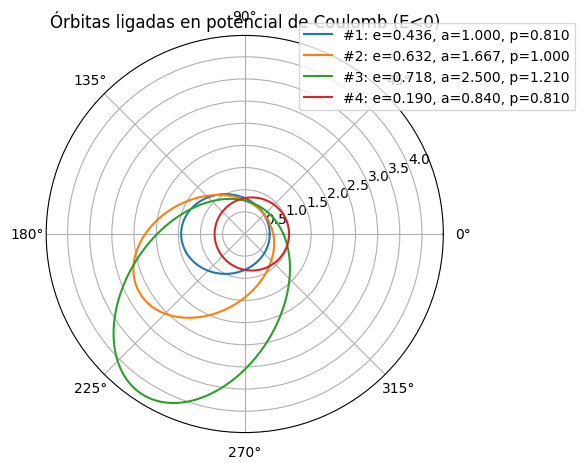

In [1]:
# Orbits in a Coulomb/Kepler potential (bound case E<0)
# -----------------------------------------------------
# Funciones para obtener la cónica desde (E,L) o desde CI,
# y para graficar r(φ) = p / (1 + e cos(φ - φ_bar)).
# Usa sólo matplotlib (sin seaborn).

import numpy as np
import matplotlib.pyplot as plt

# ---- Física ----

def params_from_EL(E, L, mu=1.0, k=1.0):
    """Devuelve (a, e, p) desde energía E(<0) y momento angular L."""
    if E >= 0:
        raise ValueError("Para órbitas ligadas necesitas E < 0.")
    a = -k/(2*E)
    e_sq = 1.0 + (2*E*L**2)/(mu*k**2)
    if e_sq < 0:  # por seguridad numérica
        e_sq = 0.0
    e = np.sqrt(e_sq)
    if not (0 <= e < 1):
        raise ValueError(f"Órbita ligada requiere 0 <= e < 1. Obtuve e={e}.")
    p = a*(1 - e**2)  # = L^2/(mu*k)
    return a, e, p

def params_from_ic(r0, phi0, rdot0, phidot0, mu=1.0, k=1.0):
    """
    Desde CI en el plano: (r0, phi0, rdot0, phidot0) -> (E, L, a, e, p, phi_bar).
    """
    L = mu * r0**2 * phidot0
    E = 0.5*mu*(rdot0**2 + (r0*phidot0)**2) - k/r0
    a, e, p = params_from_EL(E, L, mu=mu, k=k)

    # Orientación: cos(Δ) = (p/r0 - 1)/e,  sin(Δ) = (L * rdot0) / (k * e)
    cos_delta = (p/r0 - 1.0)/e if e != 0 else 1.0
    sin_delta = (L * rdot0) / (k * e) if e != 0 else 0.0
    cos_delta = np.clip(cos_delta, -1.0, 1.0)
    delta = np.arctan2(sin_delta, cos_delta)
    phi_bar = phi0 - delta
    return E, L, a, e, p, phi_bar

def r_of_phi(phi, p, e, phi_bar):
    """r(φ) = p / (1 + e cos(φ - φ_bar))."""
    return p / (1.0 + e*np.cos(phi - phi_bar))

# ---- Gráfica ----

def plot_orbits(orbits, mu=1.0, k=1.0, n_points=1000, phi_span=2*np.pi,
                filename="/mnt/data/pr3_12_trayectorias.png",
                title="Órbitas ligadas en potencial de Coulomb (E<0)"):
    """
    Dibuja múltiples órbitas en una sola figura polar.
    Cada órbita puede especificarse como:
      {'E': E, 'L': L, 'phi_bar': opcional}
    o bien
      {'r0': r0, 'phi0': phi0, 'rdot0': rdot0, 'phidot0': phidot0}
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="polar")

    phi = np.linspace(0, phi_span, n_points)

    for i, orb in enumerate(orbits, start=1):
        if {'E','L'}.issubset(orb.keys()):
            E, L = float(orb['E']), float(orb['L'])
            a, e, p = params_from_EL(E, L, mu=mu, k=k)
            phi_bar = float(orb.get('phi_bar', 0.0))
        elif {'r0','phi0','rdot0','phidot0'}.issubset(orb.keys()):
            r0, phi0 = float(orb['r0']), float(orb['phi0'])
            rdot0, phidot0 = float(orb['rdot0']), float(orb['phidot0'])
            E, L, a, e, p, phi_bar = params_from_ic(r0, phi0, rdot0, phidot0, mu=mu, k=k)
        else:
            raise ValueError("Cada órbita debe dar (E,L) o (r0,phi0,rdot0,phidot0).")

        r = r_of_phi(phi, p, e, phi_bar)
        r = np.maximum(r, 1e-12)  # evitar radios negativos por redondeo
        ax.plot(phi, r, label=f"#{i}: e={e:.3f}, a={a:.3f}, p={p:.3f}")

    ax.set_title(title)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.05))
    fig.tight_layout()
    plt.savefig(filename, dpi=160, bbox_inches="tight")
    plt.show()
    return filename

# ---- Ejemplos de uso ----

# 1) Listado con (E,L) (E<0) y orientación φ_bar opcional:
orbits_EL = [
    {'E': -0.50, 'L': 0.9, 'phi_bar': 0.0},
    {'E': -0.30, 'L': 1.0, 'phi_bar': 0.5},
    {'E': -0.20, 'L': 1.1, 'phi_bar': 1.0},
]

# 2) Una órbita desde condiciones iniciales:
orbits_IC = [
    {'r0': 1.0, 'phi0': 0.0, 'rdot0': 0.0, 'phidot0': 0.9},
]

# Combina y grafica
all_orbits = orbits_EL + orbits_IC
png_path = plot_orbits(all_orbits,
                       mu=1.0, k=1.0,
                       n_points=1200,
                       phi_span=2*np.pi,
                       filename="/mnt/data/pr3_12_trayectorias.png",
                       title="Órbitas ligadas en potencial de Coulomb (E<0)")
print("Figura guardada en:", png_path)


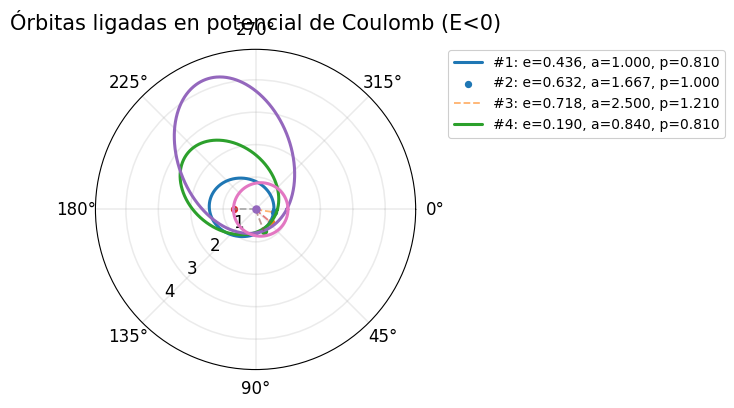

<Figure size 640x480 with 0 Axes>

In [2]:
# Orbits in a Coulomb/Kepler potential (bound case E<0) — versión estética
# -----------------------------------------------------------------------
# Mejora: tipografías más grandes, líneas más limpias, grilla suave,
# leyenda fuera del área, anotaciones del foco y periastro.

import numpy as np
import matplotlib.pyplot as plt

# ------------------ utilidades físicas ------------------

def params_from_EL(E, L, mu=1.0, k=1.0):
    if E >= 0:
        raise ValueError("Para órbitas ligadas se requiere E < 0.")
    a = -k/(2*E)
    e2 = 1.0 + (2*E*L**2)/(mu*k**2)
    e2 = max(e2, 0.0)
    e = np.sqrt(e2)
    if not (0 <= e < 1):
        raise ValueError(f"Órbita ligada exige 0<=e<1 (obtuve e={e}).")
    p = a*(1 - e**2)  # = L^2/(mu*k)
    return a, e, p

def params_from_ic(r0, phi0, rdot0, phidot0, mu=1.0, k=1.0):
    L = mu*r0**2*phidot0
    E = 0.5*mu*(rdot0**2 + (r0*phidot0)**2) - k/r0
    a, e, p = params_from_EL(E, L, mu=mu, k=k)
    # orientación
    if e == 0:
        phi_bar = 0.0
    else:
        cosD = np.clip((p/r0 - 1.0)/e, -1.0, 1.0)
        sinD = (L*rdot0)/(k*e)
        D = np.arctan2(sinD, cosD)
        phi_bar = phi0 - D
    return E, L, a, e, p, phi_bar

def r_of_phi(phi, p, e, phi_bar):
    return p / (1.0 + e*np.cos(phi - phi_bar))

# ------------------ trazo estético ------------------

def plot_orbits_pretty(orbits, mu=1.0, k=1.0, n_points=1400, phi_span=2*np.pi,
                       title="Órbitas ligadas en potencial de Coulomb (E<0)"):
    # Ajustes de estilo globales (sin tocar colores)
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "legend.fontsize": 10
    })

    fig = plt.figure(figsize=(7.2, 7.2))
    ax = fig.add_subplot(111, projection="polar")

    # cuadrícula limpia
    ax.set_theta_zero_location("E")   # 0° a la derecha
    ax.set_theta_direction(-1)        # sentido horario como convención orbital
    ax.grid(True, which="major", alpha=0.25, linewidth=1.1)
    ax.set_rlabel_position(135)       # etiquetas radiales lejos de la leyenda

    phi = np.linspace(0, phi_span, n_points)

    labels = []
    r_all = []

    for i, orb in enumerate(orbits, start=1):
        if {'E','L'}.issubset(orb.keys()):
            E, L = float(orb['E']), float(orb['L'])
            a, e, p = params_from_EL(E, L, mu=mu, k=k)
            phi_bar = float(orb.get('phi_bar', 0.0))
        elif {'r0','phi0','rdot0','phidot0'}.issubset(orb.keys()):
            r0, phi0 = float(orb['r0']), float(orb['phi0'])
            rdot0, phidot0 = float(orb['rdot0']), float(orb['phidot0'])
            E, L, a, e, p, phi_bar = params_from_ic(r0, phi0, rdot0, phidot0, mu=mu, k=k)
        else:
            raise ValueError("Cada órbita debe especificar (E,L) o (r0,phi0,rdot0,phidot0).")

        r = r_of_phi(phi, p, e, phi_bar)
        r = np.maximum(r, 1e-12)
        r_all.append(r)

        # trazo suave y nítido (sin especificar color)
        ax.plot(phi, r, linewidth=2.2, solid_joinstyle="round", solid_capstyle="round")
        labels.append(f"#{i}: e={e:.3f}, a={a:.3f}, p={p:.3f}")

        # anota periastro (r mínimo) y su radial
        r_peri = p/(1+e)
        ax.scatter([phi_bar], [r_peri], s=18)           # punto periastro
        ax.plot([phi_bar, phi_bar], [0, r_peri], linestyle="--", linewidth=1.3, alpha=0.6)

    # poner un rmax cómodo
    rmax = max(np.max(r) for r in r_all)
    ax.set_rlim(0, rmax*1.15)

    # foco en el origen
    ax.scatter([0], [0], s=26, zorder=5)  # centro de fuerzas

    # leyenda fuera del círculo
    leg = ax.legend(labels, loc="upper left", bbox_to_anchor=(1.08, 1.02), framealpha=0.95)
    leg.get_frame().set_linewidth(0.8)

    ax.set_title(title, pad=14)
    fig.tight_layout()
    plt.show()

# ------------------ ejemplo ------------------

orbits = [
    {'E': -0.50, 'L': 0.90, 'phi_bar': 0.15},
    {'E': -0.30, 'L': 1.00, 'phi_bar': 0.70},
    {'E': -0.20, 'L': 1.10, 'phi_bar': 1.20},
    {'r0': 1.0, 'phi0': 0.0, 'rdot0': 0.0, 'phidot0': 0.90},  # desde CI
]

plot_orbits_pretty(orbits, mu=1.0, k=1.0, n_points=1600, phi_span=2*np.pi)
plt.savefig("orbitas_coulomb.png", dpi=200, bbox_inches="tight")


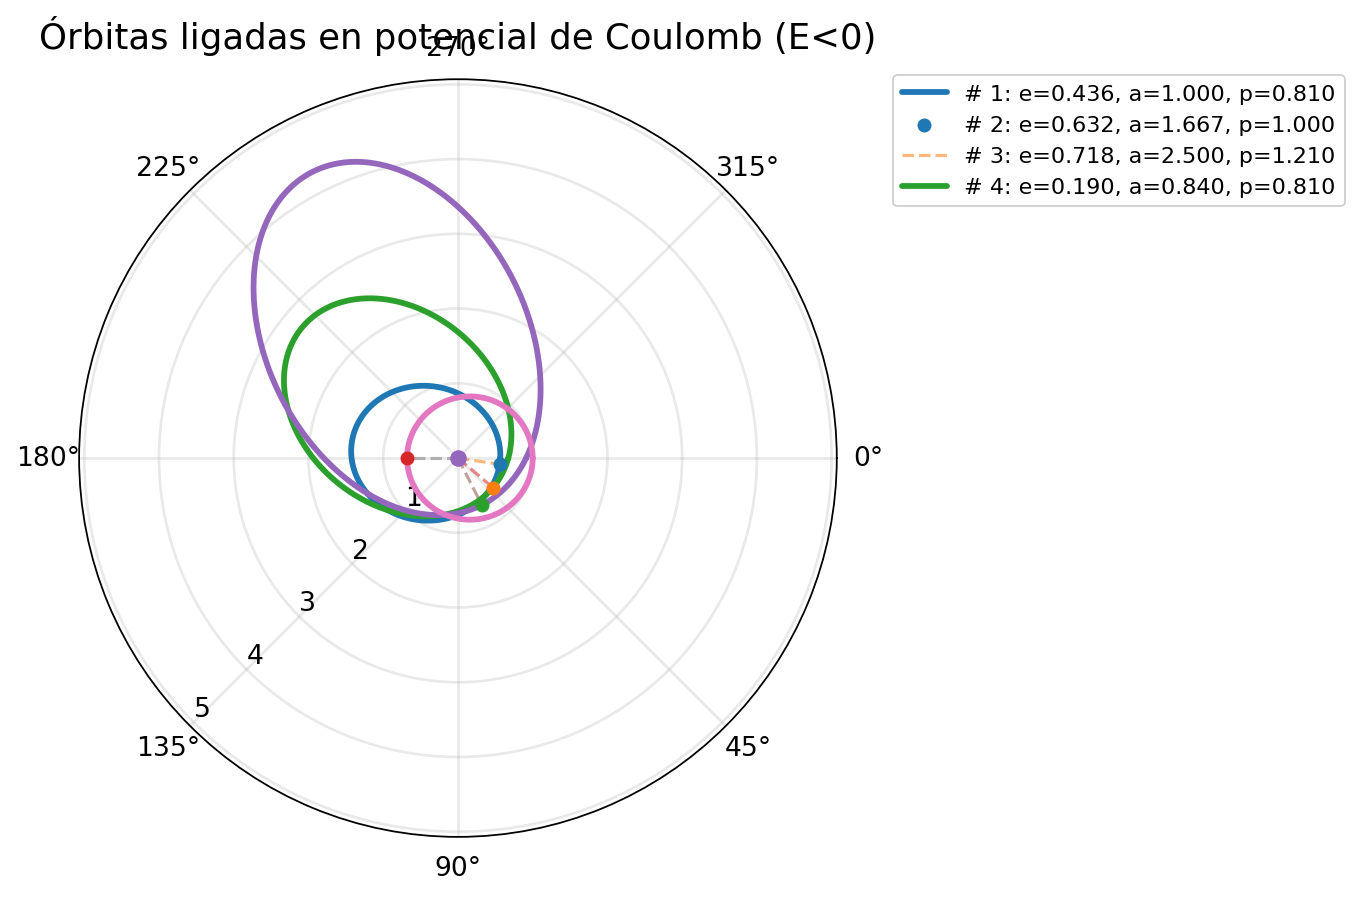

<Figure size 640x480 with 0 Axes>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =================== Utilidades físicas (Kepler/Coulomb, E<0) ===================

def params_from_EL(E, L, mu=1.0, k=1.0):
    if E >= 0:
        raise ValueError("Órbitas ligadas requieren E < 0.")
    a = -k/(2*E)
    e2 = 1.0 + (2*E*L**2)/(mu*k**2)
    e = np.sqrt(max(e2, 0.0))
    if not (0 <= e < 1):
        raise ValueError(f"Para ligadas se espera 0<=e<1 (obtuve e={e}).")
    p = a*(1 - e**2)          # también p = L^2/(mu*k)
    return a, e, p

def params_from_ic(r0, phi0, rdot0, phidot0, mu=1.0, k=1.0):
    L = mu*r0**2*phidot0
    E = 0.5*mu*(rdot0**2 + (r0*phidot0)**2) - k/r0
    a, e, p = params_from_EL(E, L, mu=mu, k=k)
    if e == 0:
        phi_bar = 0.0
    else:
        cosD = np.clip((p/r0 - 1.0)/e, -1.0, 1.0)
        sinD = (L*rdot0)/(k*e)
        D = np.arctan2(sinD, cosD)
        phi_bar = phi0 - D
    return E, L, a, e, p, phi_bar

def r_of_phi(phi, p, e, phi_bar):
    return p / (1.0 + e*np.cos(phi - phi_bar))

# =================== Gráfico cuidado (sin fijar colores) ===================

def plot_orbits_pretty(orbits, *, mu=1.0, k=1.0,
                       n_points=1600, phi_span=2*np.pi,
                       title="Órbitas ligadas en potencial de Coulomb (E<0)",
                       zero_at="E", clockwise=True):
    """
    orbits: lista de dicts, cada uno con:
      - o bien {'E':..., 'L':..., 'phi_bar': opcional}
      - o bien {'r0':..., 'phi0':..., 'rdot0':..., 'phidot0':...}
    """

    # Tipografías y DPI más limpios
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "savefig.dpi": 180
    })

    fig = plt.figure(figsize=(8.4, 8.0), dpi=160)
    ax = fig.add_subplot(111, projection="polar")

    # Orientación del eje angular
    # zero_at: "E" (0° a la derecha), "N" (arriba), etc.
    ax.set_theta_zero_location(zero_at)
    ax.set_theta_direction(-1 if clockwise else 1)

    # Cuadrícula suave
    ax.grid(True, which="major", alpha=0.28, linewidth=1.2)
    ax.set_rlabel_position(135)

    phi = np.linspace(0, phi_span, n_points)
    labels, r_all = [], []

    for i, orb in enumerate(orbits, start=1):
        if {'E','L'}.issubset(orb.keys()):
            E, L = float(orb['E']), float(orb['L'])
            a, e, p = params_from_EL(E, L, mu=mu, k=k)
            phi_bar = float(orb.get('phi_bar', 0.0))
        elif {'r0','phi0','rdot0','phidot0'}.issubset(orb.keys()):
            r0, phi0 = float(orb['r0']), float(orb['phi0'])
            rdot0, phidot0 = float(orb['rdot0']), float(orb['phidot0'])
            E, L, a, e, p, phi_bar = params_from_ic(r0, phi0, rdot0, phidot0, mu=mu, k=k)
        else:
            raise ValueError("Cada órbita debe tener (E,L) o (r0,phi0,rdot0,phidot0).")

        r = r_of_phi(phi, p, e, phi_bar)
        r = np.maximum(r, 1e-12)  # evitar negativos numéricos
        r_all.append(r)

        # Trazos nítidos (no fijamos colores)
        ax.plot(phi, r, linewidth=2.6, solid_joinstyle="round", solid_capstyle="round")

        # Periastro (punto y radial punteada)
        r_peri = p/(1+e)
        ax.scatter([phi_bar], [r_peri], s=28, zorder=5)
        ax.plot([phi_bar, phi_bar], [0, r_peri], linestyle="--", linewidth=1.4, alpha=0.55)

        labels.append(f"# {i}: e={e:.3f}, a={a:.3f}, p={p:.3f}")

    # Limite radial con margen
    rmax = max(np.max(r) for r in r_all)
    ax.set_rlim(0, rmax*1.18)

    # Foco/centro de fuerzas
    ax.scatter([0], [0], s=42, zorder=6)

    # Leyenda fuera del círculo
    leg = ax.legend(labels, loc="upper left", bbox_to_anchor=(1.06, 1.02), framealpha=0.95)
    leg.get_frame().set_linewidth(0.8)

    ax.set_title(title, pad=14)
    fig.tight_layout()
    plt.show()

# =================== Ejemplo ===================
# 1–3 por (E,L) + 1 desde condiciones iniciales
orbits = [
    {'E': -0.50, 'L': 0.90, 'phi_bar': 0.15},
    {'E': -0.30, 'L': 1.00, 'phi_bar': 0.70},
    {'E': -0.20, 'L': 1.10, 'phi_bar': 1.10},
    {'r0': 1.0, 'phi0': 0.0, 'rdot0': 0.00, 'phidot0': 0.90},  # desde CI
]

plot_orbits_pretty(orbits, mu=1.0, k=1.0, n_points=1800, phi_span=2*np.pi)
plt.savefig("orbitas_limpias.png", bbox_inches="tight")


,Case,E,L,phi_bar,p,e,a,b,r_min,r_max
0,A,-0.40000,1.00000,0.00000,1.00000,0.44721,1.25000,1.11803,0.69098,1.80902
1,B,-0.25000,1.20000,0.70000,1.44000,0.52915,2.00000,1.69706,0.94170,3.05830
2,C,-0.18000,0.90000,1.40000,0.81000,0.84167,2.77778,1.50000,0.43982,5.11574
3,D,-0.10000,0.75000,2.20000,0.56250,0.94207,5.00000,1.67705,0.28964,9.71036


CSV guardado en: orbits_points.csv


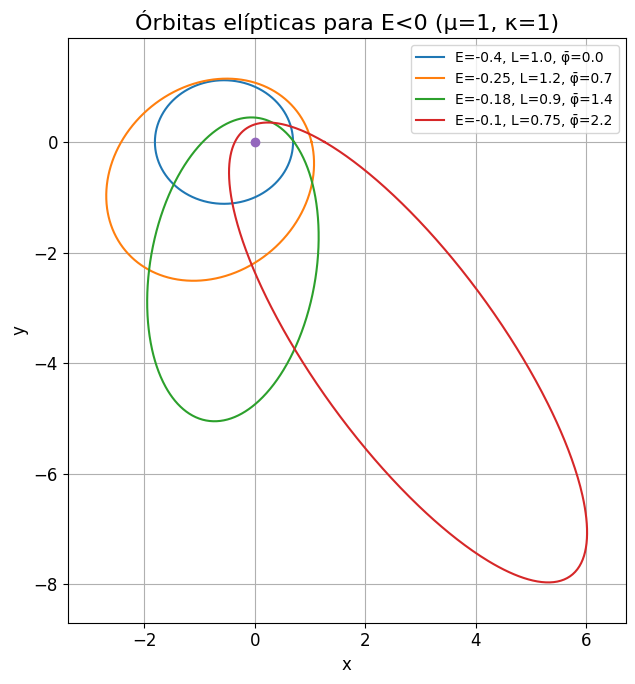

PNG guardado en: orbits_plot.png


In [4]:
# ÓRBITAS EN POTENCIAL KEPLER/COULOMB (E<0)
# Requiere: numpy, matplotlib, pandas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ----------------- Parámetros físicos (edita a gusto) -----------------
mu = 1.0      # masa reducida
kappa = 1.0   # kappa = e^2/(4*pi*eps0) en unidades elegidas

# ----------------- Casos de ejemplo (E<0, L>0) -----------------
# Cambia/añade casos: "name", "E", "L", "phi_bar" (orientación del periapsis)
cases = [
    {"name": "A", "E": -0.40, "L": 1.00, "phi_bar": 0.0},
    {"name": "B", "E": -0.25, "L": 1.20, "phi_bar": 0.7},
    {"name": "C", "E": -0.18, "L": 0.90, "phi_bar": 1.4},
    {"name": "D", "E": -0.10, "L": 0.75, "phi_bar": 2.2},
]

# ----------------- Utilidades -----------------
def orbit_params(mu, kappa, E, L):
    """Devuelve p, e, a, b, rmin, rmax para E<0"""
    p = L**2/(mu*kappa)
    e = np.sqrt(1 + 2*E*L**2/(mu*kappa**2))
    a = kappa/(-2*E)                 # semieje mayor (E<0)
    b = a*np.sqrt(1 - e**2)
    rmin = p/(1+e)
    rmax = p/(1-e)
    return p, e, a, b, rmin, rmax

def orbit_xy(mu, kappa, E, L, phi_bar=0.0, N=2000):
    """Devuelve (phi, r, x, y) de la órbita para un conjunto (E,L,phi_bar)"""
    p, e, *_ = orbit_params(mu, kappa, E, L)
    phi = np.linspace(0, 2*np.pi, N)
    r = p/(1 + e*np.cos(phi - phi_bar))
    x = r*np.cos(phi)
    y = r*np.sin(phi)
    return phi, r, x, y

# (Opcional) A partir de condiciones iniciales (r0, phi0, rdot0, phidot0)
# puedes convertir a (E,L,p,e,phi_bar). Ejemplo de función:
def params_from_initial(mu, kappa, r0, phi0, rdot0, phidot0):
    L = mu * r0**2 * phidot0
    E = 0.5 * mu * (rdot0**2 + (r0*phidot0)**2) - kappa/r0
    p = L**2/(mu*kappa)
    e = np.sqrt(1 + 2*E*L**2/(mu*kappa**2))
    # ángulo relativo theta0 = phi0 - phi_bar
    cos_theta0 = (p/r0 - 1)/e
    # proteger por redondeo numérico
    cos_theta0 = np.clip(cos_theta0, -1.0, 1.0)
    sin_theta0 = (L*rdot0)/(kappa*e)
    theta0 = np.arctan2(sin_theta0, cos_theta0)
    phi_bar = phi0 - theta0
    return dict(E=E, L=L, p=p, e=e, phi_bar=phi_bar)

# ----------------- Tabla de parámetros -----------------
rows = []
for c in cases:
    p, e, a, b, rmin, rmax = orbit_params(mu, kappa, c["E"], c["L"])
    rows.append({
        "Case": c["name"], "E": c["E"], "L": c["L"], "phi_bar": c["phi_bar"],
        "p": p, "e": e, "a": a, "b": b, "r_min": rmin, "r_max": rmax
    })
params_df = pd.DataFrame(rows)
display(params_df.style.format(precision=5))

# ----------------- Puntos para CSV -----------------
all_points = []
for c in cases:
    phi, r, x, y = orbit_xy(mu, kappa, c["E"], c["L"], c["phi_bar"])
    tmp = pd.DataFrame({"case": c["name"], "phi": phi, "r": r, "x": x, "y": y})
    all_points.append(tmp)
points_df = pd.concat(all_points, ignore_index=True)
points_df.to_csv("orbits_points.csv", index=False)
print("CSV guardado en: orbits_points.csv")

# ----------------- Figura -----------------
fig, ax = plt.subplots(figsize=(7, 7))

for c in cases:
    _, _, x, y = orbit_xy(mu, kappa, c["E"], c["L"], c["phi_bar"])
    ax.plot(x, y, label=f"E={c['E']}, L={c['L']}, φ̄={c['phi_bar']}")

# foco en el origen
ax.plot([0], [0], marker="o")

ax.set_aspect("equal", adjustable="box")
ax.grid(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Órbitas elípticas para E<0 (μ=1, κ=1)")
ax.legend(loc="upper right")

# autoencuadre con margen
xmin, xmax = points_df["x"].min(), points_df["x"].max()
ymin, ymax = points_df["y"].min(), points_df["y"].max()
dx, dy = xmax - xmin, ymax - ymin
m = 0.08
ax.set_xlim(xmin - m*dx, xmax + m*dx)
ax.set_ylim(ymin - m*dy, ymax + m*dy)

plt.tight_layout()
plt.savefig("orbits_plot.png", dpi=200)
plt.show()
print("PNG guardado en: orbits_plot.png")

# ----------------- Ejemplo opcional: construir un caso desde condiciones iniciales -----------------
# Descomenta para probar:
# r0, phi0 = 1.3, 0.3
# rdot0, phidot0 = -0.15, 0.8
# c0 = params_from_initial(mu, kappa, r0, phi0, rdot0, phidot0)
# print("Desde condiciones iniciales:", c0)
